# DAAAnalyzer_1.0.AnalyzeDPOAEs.ipynb
Created by: JFranco | Created On: 26 NOV 2024 | Last Env: QISHA | Last Run Date: 26 NOV 2024

This Python notebook will read in all DPOAE files for a specific DAA Run as specified by the user. It will make a lineplot for all availble files and label them by category. 

In [196]:
import numpy as np
import seaborn as sns
import pandas as pd
import glob
import os
import xlrd
import math
import matplotlib.pyplot as plt


In [202]:
#                *** WHAT TO ANALYZE // WHERE TO GET/STORE **
# Key identifiers
prepID = 'CMI_003'
daaRun = '1'
isoFile = 'IsoDP-'+daaRun+'-1.tsv'
fnMD = 'CMI_003.Metadata.AnimalInfo.csv'

# Directories 
#   existing ones 
dirMain = '/Users/joyfranco/Dropbox (Partners HealthCare)/JF_Shared/Data/CFTS/'
dirPrep = dirMain+prepID+'/'
dirData = dirPrep+'RawData/'
dirMD = dirPrep+'Metadata/'

#   ones that need to be made    
dirSV = dirPrep+'Results/'        

In [203]:
#    *** LOAD MD SHEETS **
# Sample metadata sheet that include animal and condition info
dfMD = pd.read_csv(dirMD+fnMD)
dfMD.reset_index(inplace=True)
dfMD

,index,AnimalID,Sex,DOB,CMIID,InjectionDate,AgeAtInjection,Package,InjGroup,NE,NEDate,AgeAtNE,NELevel,NEBand,NEDuration,NEGroup
0,0,C016,M,9/24/24,CMI_003,11/11/24,7,AAV,HABclw,Yes,11/25/24,9,97.5,8_16,2h,1
1,1,C017,F,9/24/24,CMI_003,11/11/24,7,AAV,HABclw,Yes,11/25/24,9,97.5,8_16,2h,2
2,2,C018,M,9/24/24,CMI_003,11/11/24,7,AAV,HABclw,Yes,11/25/24,9,97.5,8_16,2h,2
3,3,C019,F,9/24/24,CMI_003,11/11/24,7,AAV,MTB,Yes,11/25/24,9,97.5,8_16,2h,1
4,4,C020,M,9/24/24,CMI_003,11/11/24,7,AAV,MTB,Yes,11/25/24,9,97.5,8_16,2h,1
5,5,C021,F,9/24/24,CMI_003,11/11/24,7,AAV,MTB,Yes,11/25/24,9,97.5,8_16,2h,2
6,6,C022,M,9/24/24,CMI_003,11/11/24,7,AAV,Uninjected,Yes,11/25/24,9,97.5,8_16,2h,2
7,7,C023,F,9/24/24,CMI_003,11/11/24,7,AAV,Uninjected,Yes,11/25/24,9,97.5,8_16,2h,1


In [5]:
#           *** INITIALIZE RUN SPECIFIC DIRECTORY ETC FOR STORING RESULTS **
# Create directory for storing spreadsheetS and summary plotS for this run
if not os.path.exists(dirSV): os.mkdir(dirSV)

In [29]:
#           *** GENERATE A LIST OF DAA FOLDERS THAT WILL BE ANALYZED **
# Get a list of all the folders that match the prep
allData = os.listdir(dirData)
dataList = []
print(type(dataList))
for datum in allData:
    if ('.'+daaRun) in datum:
        dataList.append(datum)

<class 'list'>
['CMI_003.C020.1', 'CMI_003.C023.1', 'CMI_003.C016.1', 'CMI_003.C018.1', 'CMI_003.C022.1', 'CMI_003.C017.1', 'CMI_003.C019.1', 'CMI_003.C021.1']


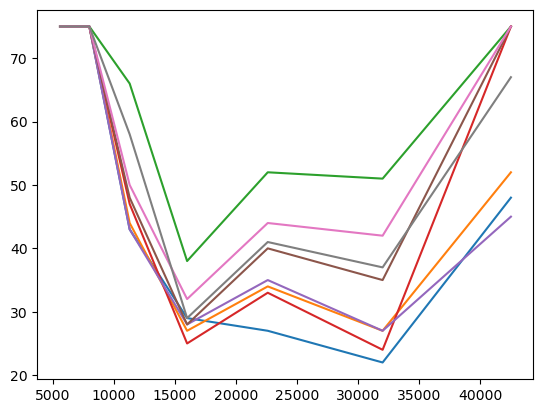

In [192]:
#           *** READ IN EACH ISOLINE TSV FILE FOR EACH DPOAE**
# Iterate through the folders
dfAll = pd.DataFrame()
for daa in dataList:
    # Setup the path to the file
    path = dirData+daa+'/'+isoFile
    # Read in the file & make adjustments for readability
    dfIso = pd.read_csv(path,  sep='\t')
    dfIso['Vals'] = dfIso.index
    # Iterate through all of the rows available and get values 
    freqs = []
    threshs = []
    for index, row in dfIso.iterrows():
        f2Freq = row['Vals'][0]
        f2Freq = int(float(f2Freq))
        if (f2Freq != 64000):
            freqs.append(f2Freq)
            thresh = row['Vals'][3]
            if thresh =='   NaN':
                thresh = 75
            threshs.append(int(float(thresh)))
    data = {'f2Freq_kHz': freqs, 'Thresh_dBSPL': threshs}
    df = pd.DataFrame(data)
    anID = daa[8:-2]
    df['AnimalID'] = anID
    df['CMIID'] = prepID
    df['DAA_Run'] = daaRun
    # Get information about this animal from the MD sheet
    dfAll = pd.concat([dfAll,df])
    plt.plot(freqs, threshs)
dfAll.reset_index(inplace=True)

(0.0, 80.0)

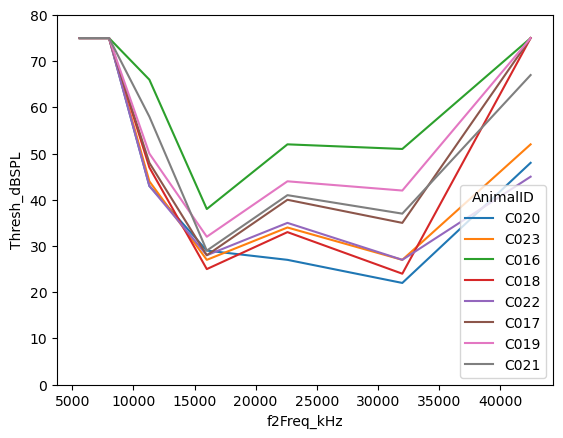

In [200]:
ax = sns.lineplot(data=dfAll, x="f2Freq_kHz", y="Thresh_dBSPL", hue="AnimalID")
plt.ylim(0,80)

In [193]:
dfAll

,index,f2Freq_kHz,Thresh_dBSPL,AnimalID,CMIID,DAA_Run
0,0,5600,75,C020,CMI_003,1
1,1,8000,75,C020,CMI_003,1
2,2,11300,43,C020,CMI_003,1
3,3,16000,29,C020,CMI_003,1
4,4,22600,27,C020,CMI_003,1
5,5,32000,22,C020,CMI_003,1
6,6,42500,48,C020,CMI_003,1
7,0,5600,75,C023,CMI_003,1
8,1,8000,75,C023,CMI_003,1
9,2,11300,44,C023,CMI_003,1


In [194]:
dfIso

,,,,,,,":Iso DP values are -5,0,5,10,15,20,and 25",Vals
5600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(5600.0, NaN, NaN, NaN, NaN, Na..."
8000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(8000.0, NaN, NaN, NaN, NaN, Na..."
11300.0,42.03,52.92,58.64,NaN,NaN,NaN,NaN,"(11300.0, 42.03, 52.92, 58.64, NaN, N..."
16000.0,21.36,25.95,29.12,32.49,36.03,39.78,44.86,"(16000.0, 21.36, 25.95, 29.12, 32.49, 36...."
22600.0,30.19,37.48,41.12,45.08,49.11,54.39,60.89,"(22600.0, 30.19, 37.48, 41.12, 45.08, 49...."
32000.0,NaN,23.85,37.32,41.54,47.84,63.58,NaN,"(32000.0, NaN, 23.85, 37.32, 41.54, 47...."
42500.0,53.26,61.89,67.60,NaN,NaN,NaN,NaN,"(42500.0, 53.26, 61.89, 67.60, NaN, N..."
64000.0,NaN,NaN,57.98,67.21,69.93,NaN,NaN,"(64000.0, NaN, NaN, 57.98, 67.21, 69...."
